# IBL brain-wide map — data exploration

Data is the public IBL brain-wide map, released under the tag `Brainwidemap`. We go through the
ONE api and the `brainbox` loaders following the official IBL docs, so anything not already in the
local cache under `./data/one_cache/` is downloaded on demand.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import brainbox.io.one as bio

# just need spike timing for the data conversion
bio.SPIKES_ATTRIBUTES = ['clusters', 'times']

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader
from iblatlas.regions import BrainRegions

# data/one_cache is the ONE cache root: <tag>/ holds the release tables, <lab>/Subjects/ the data
one = ONE(base_url='https://openalyx.internationalbrainlab.org',
          password='international',
          silent=True, cache_dir='data/one_cache')

# downloads the ~7 MB release index if it is not already cached; no data files are touched
one.load_cache(tag='Brainwidemap')

# query_type='local' searches the release index; without it the search goes to the database
eids, info = one.search(query_type='local', details=True)
sessions = pd.DataFrame(info, index=pd.Index(eids, name='eid'))

print(f'{len(sessions)} sessions, {sessions.subject.nunique()} subjects, {sessions.lab.nunique()} labs')

480 sessions, 143 subjects, 12 labs


## Sessions of one subject

`one.search` takes the same filters against the release index, so we can narrow to one subject.

In [2]:
# unique subject ids, already scoped to the loaded release index
subjects = one.list_subjects()
print(len(subjects), subjects[:8])

143 ['CSHL045', 'CSHL047', 'CSHL049', 'CSHL051', 'CSHL052', 'CSHL053', 'CSHL054', 'CSHL055']


In [3]:
subject = 'CSHL045'

# EDI identify a unique session in the release
eids, info = one.search(subject=subject, query_type='local', details=True)
for eid, session in zip(eids, info):
    print(f'{eid} {session["lab"]} {session["date"]} {session["task_protocol"]}')

7939711b-8b4d-4251-b698-b97c1eaa846e churchlandlab 2020-02-28 _iblrig_tasks_ephysChoiceWorld6.4.0
46794e05-3f6a-4d35-afb3-9165091a5a74 churchlandlab 2020-02-27 _iblrig_tasks_ephysChoiceWorld6.4.0
fa704052-147e-46f6-b190-a65b837e605e churchlandlab 2020-02-26 _iblrig_tasks_ephysChoiceWorld6.2.5
dfd8e7df-dc51-4589-b6ca-7baccfeb94b4 churchlandlab 2020-02-25 _iblrig_tasks_ephysChoiceWorld6.2.5
034e726f-b35f-41e0-8d6c-a22cc32391fb churchlandlab 2020-02-24 _iblrig_tasks_ephysChoiceWorld6.2.5


## Selecting the sessions to convert

Of the 480 released sessions 21 carry no ephys, and some are missing the whisker camera.
`one.search` filters on dataset names, so the selection is a query rather than a scan.

In [4]:
def select_sessions():
    """Released sessions that have everything the decoder needs, grouped by subject."""
    
    # set the release index to the Brainwidemap release
    one.load_cache(tag='Brainwidemap')
    
    required = ['spikes.times.npy', 'spikes.clusters.npy',          # ephys
                '_ibl_trials.table.pqt',                            # task
                '_ibl_wheel.position.npy', '_ibl_wheel.timestamps.npy']
    
    keep = set(one.search(query_type='local', datasets=required))
    left_camera = set(one.search(query_type='local', datasets=['leftCamera.ROIMotionEnergy.npy', 
                                                               '_ibl_leftCamera.times.npy']))    
    right_camera = set(one.search(query_type='local', datasets=['rightCamera.ROIMotionEnergy.npy', 
                                                                '_ibl_rightCamera.times.npy']))

    # required data + whisker motion energy from either side camera
    keep &= (left_camera | right_camera)

    # build the dictionary of subjects -> sessions
    eids, info = one.search(query_type='local', details=True)
    selected = {}
    for eid, session in zip(eids, info):
        if eid in keep:
            selected.setdefault(session['subject'], []).append(str(eid))
    return {subject: selected[subject] for subject in sorted(selected)}

all_session = select_sessions()
print(f'{sum(map(len, all_session.values()))} sessions, {len(all_session)} subjects')

# show three example subjects and their sessions IDs
for subject in list(all_session)[:3]:
    print(subject, all_session[subject])

445 sessions, 136 subjects
CSHL045 ['7939711b-8b4d-4251-b698-b97c1eaa846e', '46794e05-3f6a-4d35-afb3-9165091a5a74', 'fa704052-147e-46f6-b190-a65b837e605e', 'dfd8e7df-dc51-4589-b6ca-7baccfeb94b4', '034e726f-b35f-41e0-8d6c-a22cc32391fb']
CSHL047 ['2d5f6d81-38c4-4bdc-ac3c-302ea4d5f46e', 'b52182e7-39f6-4914-9717-136db589706e']
CSHL049 ['d839491f-55d8-4cbe-a298-7839208ba12b', 'd2918f52-8280-43c0-924b-029b2317e62c', 'c99d53e6-c317-4c53-99ba-070b26673ac4', '4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b']


## Behavioural data of one session

In [5]:
eid = all_session['CSHL059'][0]

# session loader
loader = SessionLoader(one=one, eid=eid)
loader.load_trials()
trials = loader.trials

# print trials table
print(trials.shape)
trials.head()

/home/zhangl5@hhmi.org/zhangl5/Data-Format/manual/zhang2025/.venv/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


(630, 20)


,goCueTrigger_times,intervals_bpod_0,intervals_bpod_1,quiescencePeriod,stimOffTrigger_times,stimOff_times,stimOnTrigger_times,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,probabilityLeft,feedback_times,feedbackType,rewardVolume,firstMovement_times,intervals_0,intervals_1
0,43.811841,0.0000,2.709302,0.585342,45.288556,45.357433,43.740940,43.812600,44.288546,-1.0,43.811733,NaN,1.000,0.5,44.288633,1.0,1.5,43.993567,43.148133,45.857465
1,47.261877,3.0824,6.026003,0.477752,48.605691,48.674100,47.196276,47.262600,47.605681,-1.0,47.261700,NaN,0.125,0.5,47.605767,1.0,1.5,47.426567,46.230567,49.174199
2,50.512400,6.3911,9.075902,0.692254,51.657200,51.724000,50.436100,50.513233,50.657200,1.0,50.512200,0.0,NaN,0.5,50.657300,1.0,1.5,50.406567,49.539300,52.224102
3,54.045113,9.4680,12.730302,0.472062,55.305925,55.378433,53.975212,54.045933,54.305915,-1.0,54.045000,NaN,0.125,0.5,54.306033,1.0,1.5,54.193567,52.616200,55.878532
4,57.840547,13.1023,16.530102,0.489806,59.101658,59.178267,57.770947,57.841200,58.101650,-1.0,57.840367,NaN,0.250,0.5,58.101767,1.0,1.5,57.835567,56.250533,59.678365


In [6]:
CHOICE = {1.0: 0, -1.0: 1, 0.0: 2}  # +1 is a leftward choice, -1 rightward, 0 a no response
PRIOR = {0.2: 0, 0.5: 1, 0.8: 2}    # probability that the stimulus appears on the left

def trial_variables(trials):
    """Choice, block prior and trial number in block, one row per trial."""
    # probabilityLeft is constant within a block, so a change of value starts a new block
    block = (trials.probabilityLeft != trials.probabilityLeft.shift()).cumsum()

    return pd.DataFrame({'choice': trials.choice.map(CHOICE),
                         'prior': trials.probabilityLeft.map(PRIOR),
                         'trial_in_block': trials.groupby(block).cumcount()})

variables = trial_variables(trials)

print(variables.choice.value_counts().sort_index().to_string())
print(variables.prior.value_counts().sort_index().to_string())
variables.head()

choice
0    352
1    277
2      1
prior
0    290
1     90
2    250


,choice,prior,trial_in_block
0,1,1,0
1,1,1,1
2,0,1,2
3,1,1,3
4,1,1,4


## Wheel speed and whisker motion energy

Both are continuous traces on the session clock, cut into a window around stimulus onset.
`load_wheel` already interpolates the wheel to 1000 Hz and applies the 20 Hz Butterworth filter the
IBL docs recommend, so the speed is just the absolute velocity in rad/s.

In [7]:
T_START, T_STOP, BIN = -0.5, 1.5, 0.02      # decoding window and bin size, following the reference code
TIME = np.arange(T_START, T_STOP, BIN) + BIN / 2

loader.load_wheel()
loader.load_motion_energy(views=['left'])

wheel = loader.wheel
motion_energy = loader.motion_energy['leftCamera']

def coverage(times, stim_on):
    """Trials whose window is spanned by this stream, allowing the one bin gap the reference allows."""
    start, stop = stim_on + T_START, stim_on + T_STOP
    begin = np.searchsorted(times, start, side='right')      # first sample inside the window
    end = np.searchsorted(times, stop, side='left') - 1       # last sample inside the window

    # a trial with no sample at all, or a gap at either edge, has no usable trace
    inside = begin <= end
    first = np.where(inside, times[np.clip(begin, 0, times.size - 1)], np.inf)
    last = np.where(inside, times[np.clip(end, 0, times.size - 1)], -np.inf)
    return inside & (np.abs(start - first) <= BIN) & (np.abs(stop - last) <= BIN)

def trial_traces(times, values, stim_on):
    """A continuous trace resampled onto the same time grid for every trial."""
    return np.array([np.interp(onset + TIME, times, values) for onset in stim_on])

stim_on = trials.stimOn_times.values
has_behavior = (np.isfinite(stim_on)
                & coverage(wheel.times.values, stim_on)
                & coverage(motion_energy.times.values, stim_on))

speed = trial_traces(wheel.times, np.abs(wheel.velocity), stim_on)
whisker = trial_traces(motion_energy.times, motion_energy.whiskerMotionEnergy, stim_on)

print('wheel        ', wheel.shape, '| dt = %.4f s' % np.median(np.diff(wheel.times)))
print('motion energy', motion_energy.shape, '| dt = %.4f s' % np.median(np.diff(motion_energy.times)))
print('per trial    ', speed.shape, whisker.shape)
print('trials without a full wheel or camera window:', int((~has_behavior).sum()))

/home/zhangl5@hhmi.org/zhangl5/Data-Format/manual/zhang2025/.venv/lib/python3.10/site-packages/one/util.py:464: ALFWarning: Multiple revisions: "2023-04-20", "2025-05-29"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


wheel         (4362151, 4) | dt = 0.0010 s
motion energy (260353, 2) | dt = 0.0167 s
per trial     (630, 100) (630, 100)
trials without a full wheel or camera window: 0


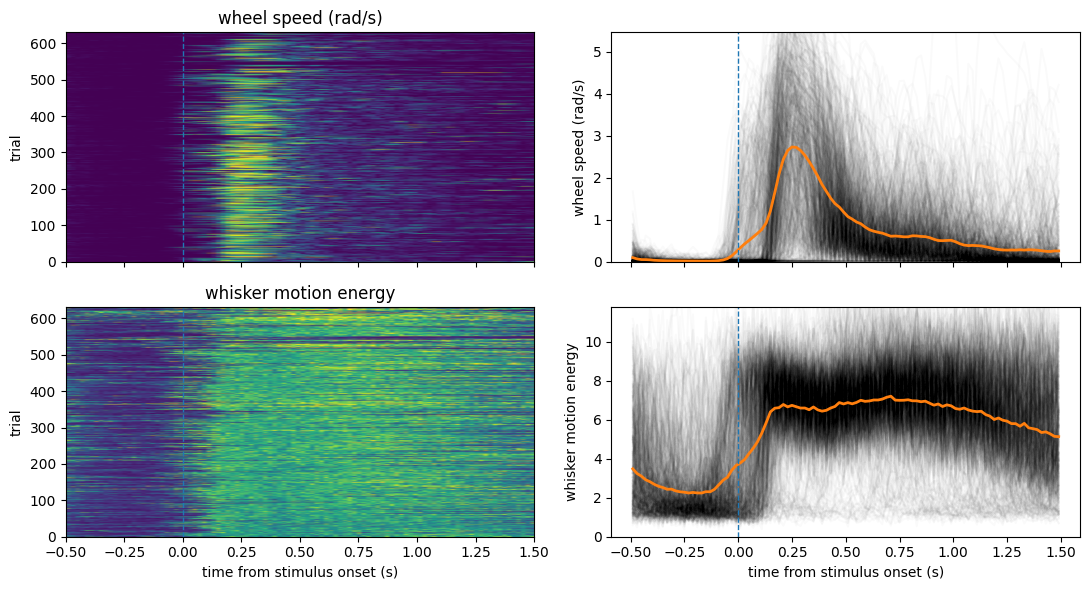

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex='col')

for row, (trace, name) in enumerate([(speed, 'wheel speed (rad/s)'),
                                     (whisker, 'whisker motion energy')]):
    axes[row, 0].imshow(trace, aspect='auto', origin='lower', vmax=np.percentile(trace, 99),
                        extent=[T_START, T_STOP, 0, len(trace)])
    axes[row, 0].set(ylabel='trial', title=name)

    axes[row, 1].plot(TIME, trace.T, color='k', alpha=0.02)
    axes[row, 1].plot(TIME, trace.mean(0), color='C1', lw=2)
    axes[row, 1].set(ylabel=name, ylim=(0, np.percentile(trace, 99.5)))

    for ax in axes[row]:
        ax.axvline(0, color='C0', ls='--', lw=1)      # stimulus onset

axes[1, 0].set_xlabel('time from stimulus onset (s)')
axes[1, 1].set_xlabel('time from stimulus onset (s)')
plt.tight_layout()

## Neural data

A session can have more than one probe, so the good units of each are merged into one population.
The data paper applies "stringent quality-control metrics" to get its well-isolated neurons; that
cut is the `label` column of the cluster metrics, and `label >= 1` reproduces the published count.

In [9]:
EDGES = np.arange(T_START, T_STOP + BIN / 2, BIN)
brain_regions = BrainRegions()

def load_neural(eid):
    """Spike times and good clusters of a session, merged over its probes."""
    times, units, regions = [], [], []
    for pid, name in zip(*one.eid2pid(eid)):
        loader = SpikeSortingLoader(pid=pid, one=one, eid=eid, pname=name)
        spikes, clusters, channels = loader.load_spike_sorting()
        clusters = loader.merge_clusters(spikes, clusters, channels)   # attaches metrics and histology

        good = np.flatnonzero(clusters['label'] >= 1)                  # the quality control of the paper
        keep = np.isin(spikes['clusters'], good)

        # renumber the surviving clusters, continuing the count from the previous probe
        units.append(np.searchsorted(good, spikes['clusters'][keep]) + len(regions))
        times.append(spikes['times'][keep])

        # Beryl is the coarser atlas the reference code uses, e.g. DG-sg and DG-mo both become DG
        regions.extend(brain_regions.acronym2acronym(clusters['acronym'][good], mapping='Beryl'))
        print(f'{name}: {len(clusters["label"])} clusters -> {len(good)} good')

    return np.concatenate(times), np.concatenate(units), np.array(regions)

def spike_counts(times, units, n_units, stim_on):
    """Spike count per unit and bin, for every trial."""
    counts = np.empty((stim_on.size, n_units, EDGES.size - 1))
    for trial, onset in enumerate(stim_on):
        window = (times >= onset + T_START) & (times < onset + T_STOP)
        counts[trial] = np.histogram2d(units[window], times[window] - onset,
                                       bins=[np.arange(n_units + 1) - 0.5, EDGES])[0]
    return counts

spike_times, spike_units, regions = load_neural(eid)
rate = spike_counts(spike_times, spike_units, regions.size, stim_on) / BIN

print('units', regions.size, '| rate', rate.shape, '| mean %.1f Hz' % rate.mean())
print('regions', pd.Series(regions).value_counts().head(6).to_dict())

probe00: 682 clusters -> 117 good
probe01: 1094 clusters -> 76 good
units 193 | rate (630, 193, 100) | mean 17.0 Hz
regions {'CP': 62, 'DG': 33, 'COAa': 16, 'CA1': 15, 'FS': 15, 'MRN': 15}


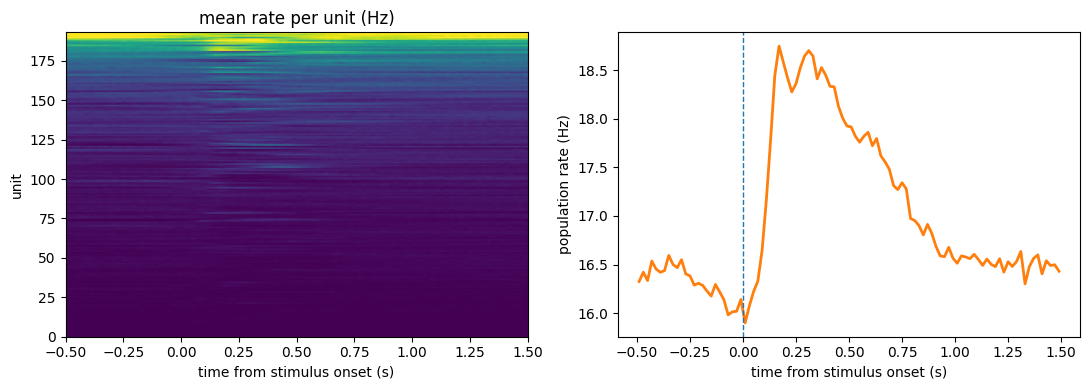

In [10]:
psth = rate.mean(axis=0)                                   # unit by time
order = np.argsort(psth.mean(1))                      # quietest unit at the bottom

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(psth[order], aspect='auto', origin='lower', vmax=np.percentile(psth, 99),
               extent=[T_START, T_STOP, 0, len(psth)])
axes[0].set(xlabel='time from stimulus onset (s)', ylabel='unit', title='mean rate per unit (Hz)')

axes[1].plot(TIME, rate.mean((0, 1)), color='C1', lw=2)
axes[1].axvline(0, color='C0', ls='--', lw=1)
axes[1].set(xlabel='time from stimulus onset (s)', ylabel='population rate (Hz)')
plt.tight_layout()